# Project 02 — Customer Behavior Analysis for the CEO
### *The First Day as a Junior Data Analyst*

**Scenario:** I've just joined the e-commerce company as a Junior Data Analyst. The CEO needs a data-driven briefing before the next management meeting. This notebook uses the cleaned customer dataset (output of Project 01) to answer the six required business questions, followed by a clearly separated **Additional Analysis** section (statistical testing, RFM segmentation, K-Means clustering, and a supervised churn model) that goes beyond the brief.

All file paths below are **relative** to this notebook's folder, so it runs on any machine without editing paths.

**Guiding question:** *How can this analysis help the CEO make better business decisions?*


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.width", 120)

RNG = 42

# relative path -> works on any machine, e.g. after `git clone`
df = pd.read_excel("dataset/cleaned_dataset.xlsx")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.head()


Rows: 60  |  Columns: 17


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,True,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,False,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,True,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,False,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,True,7,4


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         60 non-null     int64         
 1   first_name          60 non-null     object        
 2   gender              60 non-null     object        
 3   age                 60 non-null     int64         
 4   city                60 non-null     object        
 5   province            60 non-null     object        
 6   signup_date         60 non-null     datetime64[ns]
 7   membership_tier     60 non-null     object        
 8   purchase_count      60 non-null     int64         
 9   avg_order_value     60 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  60 non-null     int64         
 12  payment_method      60 non-null     object        
 13  device              60 non-null     object        
 

In [9]:
print("Missing values (total):", df.isnull().sum().sum())
df.describe(include="all").T


Missing values (total): 0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,60.0,NaN,NaN,NaN,1030.5,1001.0,1015.75,1030.5,1045.25,1060.0,17.464249
first_name,60,12,Sina,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,60,2,M,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,60.0,NaN,NaN,NaN,43.7,19.0,31.75,45.0,58.0,65.0,13.946994
city,60,8,Tabriz,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,60,8,East Azerbaijan,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,60,NaN,NaN,NaN,2023-02-03 14:00:00,2021-02-23 00:00:00,2021-12-06 12:00:00,2022-08-15 00:00:00,2024-06-14 12:00:00,2025-09-09 00:00:00,NaN
membership_tier,60,4,Gold,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_count,60.0,NaN,NaN,NaN,17.383333,0.0,10.75,17.0,24.5,35.0,10.14988
avg_order_value,60.0,NaN,NaN,NaN,213.1565,27.63,108.1375,165.435,324.1075,449.81,130.509923


No missing values remain (the dataset was already cleaned in Project 01). We have **60 customers** and **17 attributes** covering demographics, purchase behavior, engagement channel, and satisfaction.

## Question 1 — Customer Profile & Dominant Persona

Building the customer profile the CEO would want on slide one: who are our customers, in terms of **Age Group, Gender, Membership Tier, Device, and Payment Method**.


In [10]:
df["age_group"] = pd.cut(df["age"], bins=[17, 25, 35, 45, 55, 65],
                          labels=["18-25", "26-35", "36-45", "46-55", "56-65"])

profile_tables = {
    "Age Group": df["age_group"].value_counts().sort_index(),
    "Gender": df["gender"].value_counts(),
    "Membership Tier": df["membership_tier"].value_counts(),
    "Device": df["device"].value_counts(),
    "Payment Method": df["payment_method"].value_counts(),
}
for name, tbl in profile_tables.items():
    print(f"--- {name} ---")
    print(tbl.to_string())
    print()


--- Age Group ---
age_group
18-25    10
26-35     9
36-45    13
46-55    11
56-65    17

--- Gender ---
gender
M    35
F    25

--- Membership Tier ---
membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8

--- Device ---
device
Android    22
Web        20
iPhone     18

--- Payment Method ---
payment_method
Online Wallet    23
Cash             19
Card             18



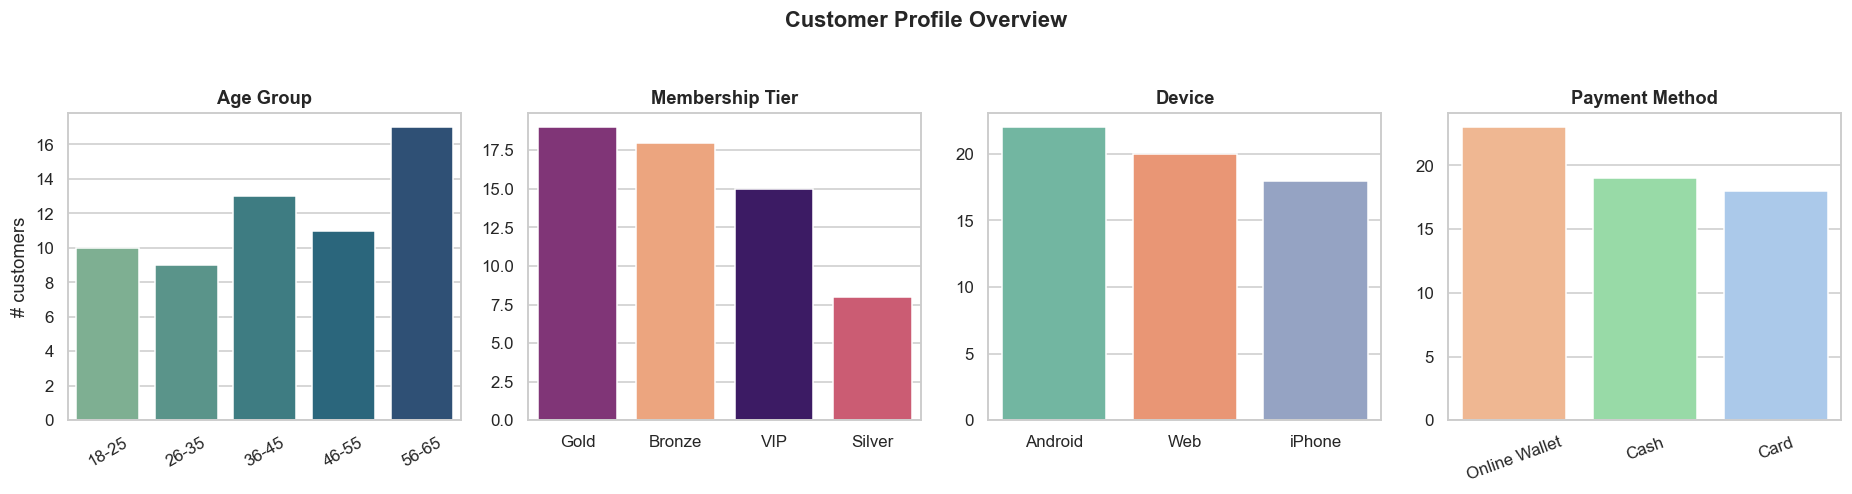

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))

sns.countplot(data=df, x="age_group", order=["18-25","26-35","36-45","46-55","56-65"],
              hue="age_group", palette="crest", ax=axes[0], legend=False)
axes[0].set_title("Age Group"); axes[0].set_xlabel(""); axes[0].set_ylabel("# customers")
axes[0].tick_params(axis="x", rotation=30)

tier_order = df["membership_tier"].value_counts().index
sns.countplot(data=df, x="membership_tier", order=tier_order, hue="membership_tier",
              palette="magma", ax=axes[1], legend=False)
axes[1].set_title("Membership Tier"); axes[1].set_xlabel(""); axes[1].set_ylabel("")

dev_order = df["device"].value_counts().index
sns.countplot(data=df, x="device", order=dev_order, hue="device", palette="Set2", ax=axes[2], legend=False)
axes[2].set_title("Device"); axes[2].set_xlabel(""); axes[2].set_ylabel("")

pay_order = df["payment_method"].value_counts().index
sns.countplot(data=df, x="payment_method", order=pay_order, hue="payment_method",
              palette="pastel", ax=axes[3], legend=False)
axes[3].set_title("Payment Method"); axes[3].set_xlabel(""); axes[3].set_ylabel("")
axes[3].tick_params(axis="x", rotation=20)

plt.suptitle("Customer Profile Overview", fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("charts/01_customer_profile.png", bbox_inches="tight")
plt.show()


In [12]:
persona = {
    "Age Group": df["age_group"].mode()[0],
    "Gender": df["gender"].mode()[0],
    "Membership Tier": df["membership_tier"].mode()[0],
    "Device": df["device"].mode()[0],
    "Payment Method": df["payment_method"].mode()[0],
}
persona_series = pd.Series(persona, name="Most common value")
persona_series


Age Group                  56-65
Gender                         M
Membership Tier             Gold
Device                   Android
Payment Method     Online Wallet
Name: Most common value, dtype: object

**Dominant Customer Persona:** a **male customer aged 56–65**, on the **Gold** membership tier, shopping via **Android**, paying with an **Online Wallet**. Gender skews male (35 vs. 25 female, 58%/42%), and the 56–65 age band is the single largest group (17 of 60 customers, 28%) — this is an **older customer base than a typical e-commerce assumption**, which should inform tone, UX, and channel choices in marketing creative rather than defaulting to a younger-skewing campaign style.


## Question 2 — Province & City Analysis, and Campaign Recommendation

Grouped by **Province + City** (each city maps to exactly one province in this dataset, so the combined table is one row per city) on **Customer Count, Total/Average Spending, Average Purchase Count, Average Order Value, and Average Satisfaction**.


In [13]:
city_stats = df.groupby(["province", "city"]).agg(
    customers=("customer_id", "count"),
    total_revenue=("total_spending", "sum"),
    avg_spending=("total_spending", "mean"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_order_value=("avg_order_value", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
).round(2).sort_values("total_revenue", ascending=False)
city_stats["revenue_share_%"] = (city_stats["total_revenue"] / total_revenue * 100).round(1) if "total_revenue" in dir() else None
city_stats["revenue_share_%"] = (city_stats["total_revenue"] / df["total_spending"].sum() * 100).round(1)
city_stats


,,customers,total_revenue,avg_spending,avg_purchase_count,avg_order_value,avg_satisfaction,revenue_share_%
province,city,,,,,,,
Khorasan,Mashhad,11,43197.58,3927.05,22.64,210.51,2.91,21.4
East Azerbaijan,Tabriz,12,36192.49,3016.04,15.75,238.90,3.00,17.9
Alborz,Karaj,7,26189.81,3741.40,16.00,211.44,2.86,13.0
Khuzestan,Ahvaz,8,23384.78,2923.10,13.88,216.53,3.50,11.6
Isfahan,Isfahan,5,21975.32,4395.06,19.80,212.68,4.40,10.9
Fars,Shiraz,6,20715.92,3452.65,16.33,180.98,2.00,10.3
Gilan,Rasht,5,15168.54,3033.71,16.40,241.55,2.60,7.5
Tehran,Tehran,6,15161.29,2526.88,17.17,172.93,2.67,7.5


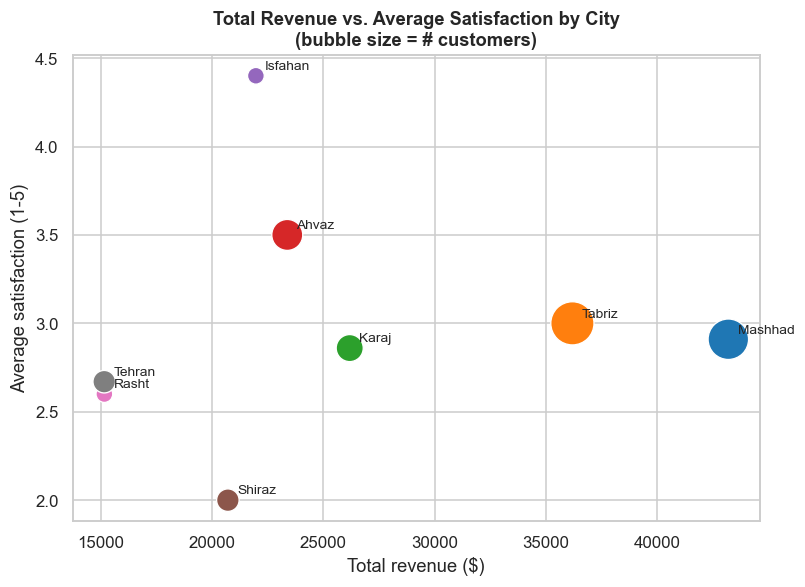

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
city_plot = city_stats.reset_index()
sns.scatterplot(data=city_plot, x="total_revenue", y="avg_satisfaction", size="customers",
                 sizes=(120, 800), hue="city", palette="tab10", legend=False, ax=ax)
for _, r in city_plot.iterrows():
    ax.annotate(r["city"], (r["total_revenue"], r["avg_satisfaction"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set_title("Total Revenue vs. Average Satisfaction by City\n(bubble size = # customers)")
ax.set_xlabel("Total revenue ($)")
ax.set_ylabel("Average satisfaction (1-5)")
plt.tight_layout()
plt.savefig("charts/02_city_revenue_vs_satisfaction.png", bbox_inches="tight")
plt.show()


In [15]:
most_customers_city = df["city"].value_counts().idxmax()
most_customers_n = df["city"].value_counts().max()
top_rev_city = city_stats["total_revenue"].idxmax()[1]
top_rev_n = city_stats.reset_index().set_index("city").loc[top_rev_city, "customers"]

print(f"Most customers: {most_customers_city} ({most_customers_n} customers)")
print(f"Highest total revenue: {top_rev_city} "
      f"({city_stats['total_revenue'].max():,.0f} = "
      f"{city_stats['revenue_share_%'].max()}% of revenue, {top_rev_n} customers)")


Most customers: Tabriz (12 customers)
Highest total revenue: Mashhad (43,198 = 21.4% of revenue, 11 customers)


**Correction from an earlier draft:** the city with the *most customers* is actually **Tabriz (12 customers)**, not Mashhad — Mashhad has 11. Mashhad is still the right recommendation, but for the correct reason.

**Recommendation: Mashhad.**
Mashhad has the **highest total revenue** (~21% of company revenue, 11 customers) and average satisfaction in line with the company mean, even though Tabriz has slightly more customers (12) — Mashhad's customer base converts to more revenue per head. **Isfahan** stands out with the highest average satisfaction (4.4/5) and strong average spending, but with only 5 customers it's better suited to a small, high-touch pilot than the lead campaign city.


## Question 3 — Top 10 Valuable Customers (Composite Loyalty Score)

Ranking by `total_spending` alone would miss customers who are highly engaged but haven't spent the most yet, and could reward one-time big spenders who never come back. Instead I build a **Loyalty Score** that combines all four relevant signals:

- **Monetary** — `total_spending` (35% weight — still the strongest signal of value)
- **Frequency** — `purchase_count` (25%)
- **Recency** — inverse of `last_purchase_days` (20% — more recent = better)
- **Satisfaction** — `satisfaction_score` (20%)

Each factor is min-max normalized to 0–1 before weighting, so no single unit (dollars vs. counts vs. days) dominates just because of its scale.


In [16]:
def normalize(s):
    return (s - s.min()) / (s.max() - s.min())

df["spend_score"]    = normalize(df["total_spending"])
df["frequency_score"] = normalize(df["purchase_count"])
df["recency_score"]  = 1 - normalize(df["last_purchase_days"])   # more recent -> higher score
df["satisfaction_norm"] = normalize(df["satisfaction_score"])

WEIGHTS = {"spend": 0.35, "frequency": 0.25, "recency": 0.20, "satisfaction": 0.20}

df["loyalty_score"] = 100 * (
    WEIGHTS["spend"]        * df["spend_score"]
  + WEIGHTS["frequency"]    * df["frequency_score"]
  + WEIGHTS["recency"]      * df["recency_score"]
  + WEIGHTS["satisfaction"] * df["satisfaction_norm"]
)

top10 = (df.sort_values("loyalty_score", ascending=False).head(10)[
    ["customer_id", "first_name", "city", "membership_tier", "total_spending",
     "purchase_count", "last_purchase_days", "satisfaction_score", "loyalty_score"]
].reset_index(drop=True))
top10.index = top10.index + 1
top10.round(1)


,customer_id,first_name,city,membership_tier,total_spending,purchase_count,last_purchase_days,satisfaction_score,loyalty_score
1,1057,Maryam,Ahvaz,Bronze,13532.7,31,82,4,85.8
2,1044,Mina,Shiraz,Gold,14354.3,33,165,2,74.6
3,1059,Ali,Isfahan,Gold,8898.6,31,224,5,71.6
4,1009,Kimia,Karaj,Silver,11615.4,34,232,2,65.0
5,1033,Neda,Tabriz,VIP,5521.2,24,112,5,64.6
6,1004,Sina,Mashhad,Gold,6121.4,23,40,4,64.3
7,1012,Arash,Mashhad,Gold,11731.5,27,224,2,60.7
8,1014,Reza,Tabriz,VIP,3353.9,31,97,4,60.1
9,1020,Kimia,Isfahan,Bronze,2994.7,16,4,5,58.7
10,1023,Ali,Mashhad,Bronze,3851.4,31,170,4,57.3


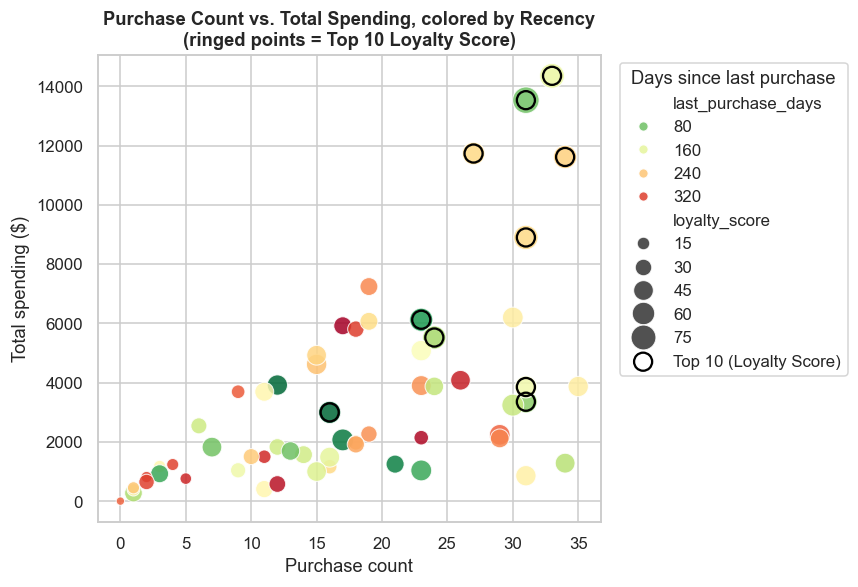

In [17]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df, x="purchase_count", y="total_spending", hue="last_purchase_days",
                 size="loyalty_score", sizes=(30, 300), palette="RdYlGn_r", alpha=0.85)
top10_ids = top10["customer_id"].tolist()
highlight = df[df["customer_id"].isin(top10_ids)]
plt.scatter(highlight["purchase_count"], highlight["total_spending"],
            s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="Top 10 (Loyalty Score)")
plt.title("Purchase Count vs. Total Spending, colored by Recency\n(ringed points = Top 10 Loyalty Score)")
plt.xlabel("Purchase count"); plt.ylabel("Total spending ($)")
plt.legend(title="Days since last purchase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("charts/03_top10_loyalty.png", bbox_inches="tight")
plt.show()


In [18]:
for _, r in top10.iterrows():
    reasons = []
    if r["total_spending"] >= df["total_spending"].quantile(0.75):
        reasons.append("top-quartile spend")
    if r["purchase_count"] >= df["purchase_count"].quantile(0.75):
        reasons.append("very frequent buyer")
    if r["last_purchase_days"] <= df["last_purchase_days"].quantile(0.25):
        reasons.append("purchased very recently")
    if r["satisfaction_score"] >= 4:
        reasons.append("highly satisfied")
    if not reasons:
        reasons.append("strong, well-rounded balance across spend/frequency/recency/satisfaction")
    print(f"#{r['customer_id']} {r['first_name']} ({r['city']}, {r['membership_tier']}) "
          f"- Loyalty Score {r['loyalty_score']:.1f}: {', '.join(reasons)}")


#1057 Maryam (Ahvaz, Bronze) - Loyalty Score 85.8: top-quartile spend, very frequent buyer, purchased very recently, highly satisfied
#1044 Mina (Shiraz, Gold) - Loyalty Score 74.6: top-quartile spend, very frequent buyer
#1059 Ali (Isfahan, Gold) - Loyalty Score 71.6: top-quartile spend, very frequent buyer, highly satisfied
#1009 Kimia (Karaj, Silver) - Loyalty Score 65.0: top-quartile spend, very frequent buyer
#1033 Neda (Tabriz, VIP) - Loyalty Score 64.6: top-quartile spend, purchased very recently, highly satisfied
#1004 Sina (Mashhad, Gold) - Loyalty Score 64.3: top-quartile spend, purchased very recently, highly satisfied
#1012 Arash (Mashhad, Gold) - Loyalty Score 60.7: top-quartile spend, very frequent buyer
#1014 Reza (Tabriz, VIP) - Loyalty Score 60.1: very frequent buyer, purchased very recently, highly satisfied
#1020 Kimia (Isfahan, Bronze) - Loyalty Score 58.7: purchased very recently, highly satisfied
#1023 Ali (Mashhad, Bronze) - Loyalty Score 57.3: very frequent buye

**Takeaway:** using a composite score rather than raw spend changes the list — some customers make the top 10 primarily on frequency and recency even without being the single biggest spenders, while a couple of very-high-spend-but-long-inactive customers *drop out* of the list entirely. This is a more defensible basis for a loyalty campaign than sorting by one column.


## Question 4 — Valuable Customers at Risk of Churning

A customer only counts as a **valuable customer at risk** if **all three** are true:
- **Value**: `total_spending` ≥ median **and** `purchase_count` ≥ median (so a zero-spend customer can never qualify)
- **Inactivity**: `last_purchase_days` is in the worst quartile (≥ 75th percentile)

This is different from — and stricter than — simply "inactive and unhappy." It deliberately separates **why** a valuable customer might be at risk into two distinct groups that need two different responses.


In [19]:
spend_median = df["total_spending"].median()
freq_median  = df["purchase_count"].median()
recency_p75  = df["last_purchase_days"].quantile(0.75)

is_valuable = (df["total_spending"] >= spend_median) & (df["purchase_count"] >= freq_median)
is_inactive = df["last_purchase_days"] >= recency_p75
df["at_risk_valuable"] = is_valuable & is_inactive

at_risk = df[df["at_risk_valuable"]][
    ["customer_id", "first_name", "city", "total_spending", "purchase_count",
     "last_purchase_days", "satisfaction_score", "membership_tier"]
].sort_values("total_spending", ascending=False)

print(f"Spend median: ${spend_median:,.0f}  |  Purchase-count median: {freq_median:.0f}  |  "
      f"Recency 75th pct: {recency_p75:.0f} days")
print(f"Valuable customers at risk: {len(at_risk)} of {len(df)} "
      f"({len(at_risk)/len(df):.1%}) — revenue at stake: ${at_risk['total_spending'].sum():,.0f}")
at_risk


Spend median: $2,129  |  Purchase-count median: 17  |  Recency 75th pct: 274 days
Valuable customers at risk: 6 of 60 (10.0%) — revenue at stake: $27,422


,customer_id,first_name,city,total_spending,purchase_count,last_purchase_days,satisfaction_score,membership_tier
9,1010,Arash,Karaj,7241.47,19,276,1,Silver
34,1035,Arash,Tabriz,5918.21,17,365,3,Bronze
52,1053,Sina,Tehran,5805.54,18,320,1,Gold
29,1030,Sina,Mashhad,4079.14,26,340,4,VIP
6,1007,Reza,Rasht,2237.35,29,298,5,VIP
48,1049,Ali,Mashhad,2140.38,23,357,1,Gold


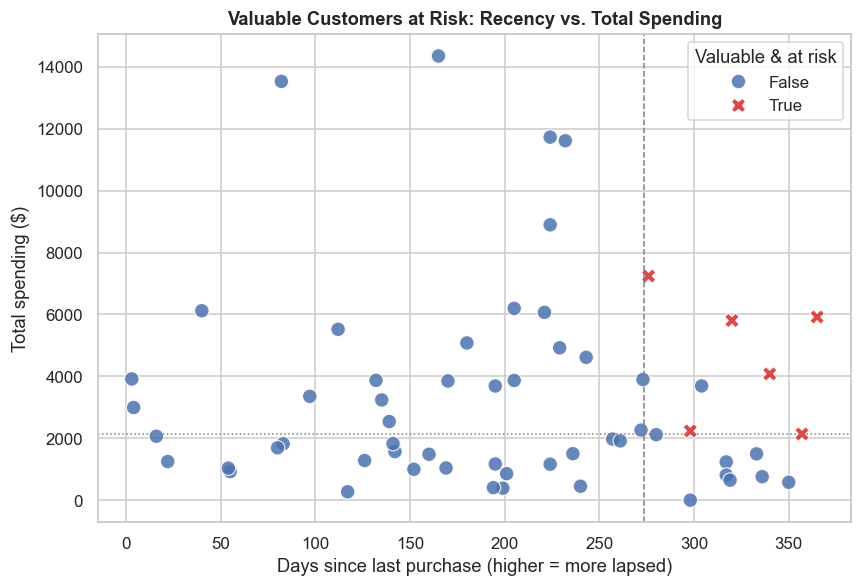

In [20]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df, x="last_purchase_days", y="total_spending",
                 hue="at_risk_valuable", palette={True: "#d62728", False: "#4c72b0"},
                 style="at_risk_valuable", s=90, alpha=0.85)
plt.axvline(recency_p75, color="gray", linestyle="--", linewidth=1)
plt.axhline(spend_median, color="gray", linestyle=":", linewidth=1)
plt.title("Valuable Customers at Risk: Recency vs. Total Spending")
plt.xlabel("Days since last purchase (higher = more lapsed)")
plt.ylabel("Total spending ($)")
plt.legend(title="Valuable & at risk", loc="upper right")
plt.tight_layout()
plt.savefig("charts/04_valuable_at_risk.png", bbox_inches="tight")
plt.show()


In [21]:
dissatisfied = at_risk[df.loc[at_risk.index, "satisfaction_score"] <= 2]
satisfied_inactive = at_risk[df.loc[at_risk.index, "satisfaction_score"] >= 3]
print(f"Dissatisfied at-risk (satisfaction <= 2): {len(dissatisfied)}")
print(f"Satisfied-but-inactive at-risk (satisfaction >= 3): {len(satisfied_inactive)}")


Dissatisfied at-risk (satisfaction <= 2): 3
Satisfied-but-inactive at-risk (satisfaction >= 3): 3


**6 customers** are simultaneously valuable and going quiet, worth **~$27,422** in historical revenue. They split into two groups that need different treatment:

- **Dissatisfied at-risk (3 customers, satisfaction ≤ 2):** something went wrong. **Action:** a proactive, human outreach — acknowledge the issue, offer a concrete fix or make-good (refund/credit for a bad experience), not a generic discount.
- **Satisfied-but-inactive at-risk (3 customers, satisfaction ≥ 3):** they liked the service but simply drifted away — no complaint to fix. **Action:** a lightweight re-engagement nudge (new arrivals, a "we miss you" reminder, or a small time-limited incentive) rather than an apology they don't need.

Treating both groups the same (as a single "at risk" bucket) would waste an apology on people who have no complaint, or waste a discount on someone who actually needs a service recovery.


## Question 5 — Discount Users vs. Non-Users (incl. Device & Payment Method)

Does offering a discount actually change customer behavior? I look at spending, frequency, satisfaction, and returns — and, since *how* people pay and shop is part of the same behavioral picture, I fold the device and payment-method breakdown into this same question rather than treating it separately.


In [22]:
disc_compare = df.groupby("discount_used")[
    ["avg_order_value", "total_spending", "purchase_count", "satisfaction_score", "returned_items"]
].mean().round(2)
disc_compare.index = disc_compare.index.map({True: "Used discount", False: "No discount"})
disc_compare


,avg_order_value,total_spending,purchase_count,satisfaction_score,returned_items
discount_used,,,,,
No discount,220.70,3736.74,17.29,2.76,3.97
Used discount,203.29,2882.17,17.50,3.27,3.58


In [23]:
t_spend, p_spend = stats.ttest_ind(df.loc[df.discount_used, "total_spending"],
                                    df.loc[~df.discount_used, "total_spending"], equal_var=False)
t_sat, p_sat = stats.ttest_ind(df.loc[df.discount_used, "satisfaction_score"],
                                df.loc[~df.discount_used, "satisfaction_score"], equal_var=False)
t_freq, p_freq = stats.ttest_ind(df.loc[df.discount_used, "purchase_count"],
                                  df.loc[~df.discount_used, "purchase_count"], equal_var=False)

print(f"Total spending  -> t={t_spend:.2f}, p={p_spend:.3f}  {'(significant)' if p_spend<0.05 else '(not significant at 5%)'}")
print(f"Satisfaction    -> t={t_sat:.2f}, p={p_sat:.3f}  {'(significant)' if p_sat<0.05 else '(not significant at 5%)'}")
print(f"Purchase count  -> t={t_freq:.2f}, p={p_freq:.3f}  {'(significant)' if p_freq<0.05 else '(not significant at 5%)'}")


Total spending  -> t=-1.05, p=0.297  (not significant at 5%)
Satisfaction    -> t=1.35, p=0.184  (not significant at 5%)
Purchase count  -> t=0.08, p=0.939  (not significant at 5%)


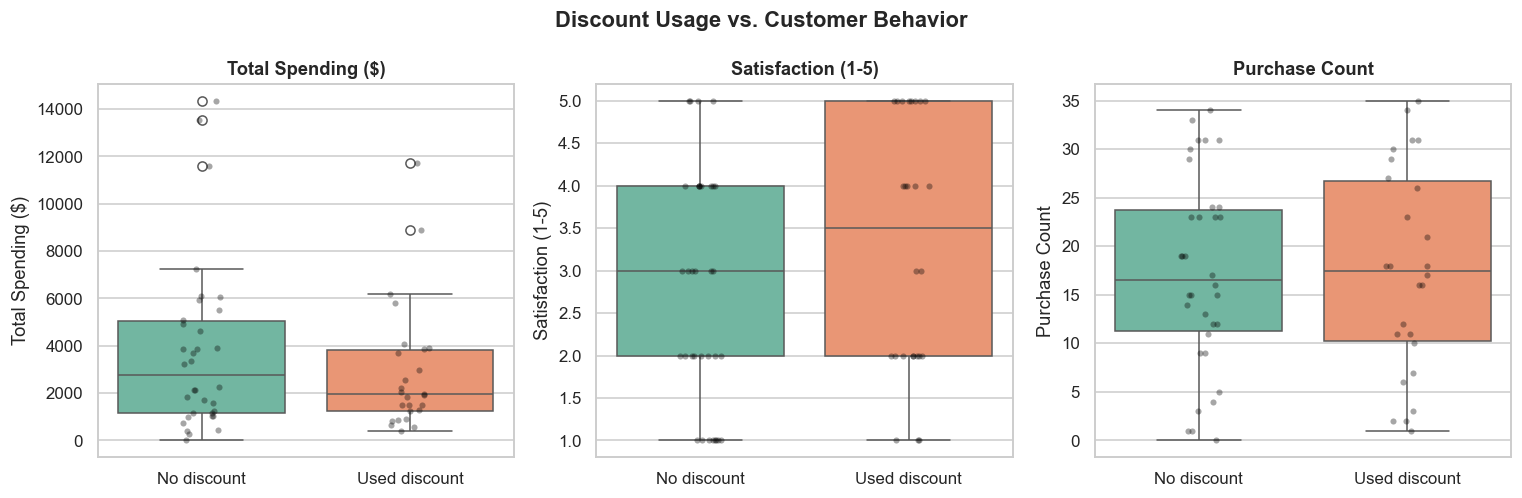

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
metrics = [("total_spending", "Total Spending ($)"), ("satisfaction_score", "Satisfaction (1-5)"),
           ("purchase_count", "Purchase Count")]
for ax, (col, label) in zip(axes, metrics):
    sns.boxplot(data=df, x="discount_used", y=col, hue="discount_used", palette="Set2", ax=ax, legend=False)
    sns.stripplot(data=df, x="discount_used", y=col, color="black", alpha=0.35, size=4, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No discount", "Used discount"])
    ax.set_xlabel(""); ax.set_ylabel(label); ax.set_title(label)
plt.suptitle("Discount Usage vs. Customer Behavior", fontweight="bold")
plt.tight_layout()
plt.savefig("charts/05a_discount_comparison.png", bbox_inches="tight")
plt.show()


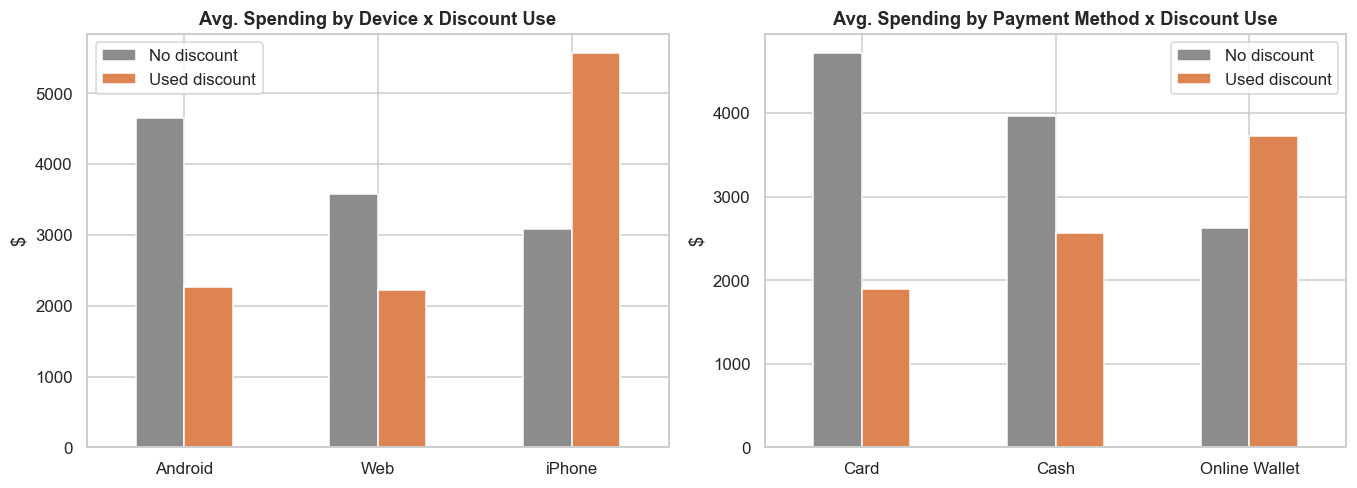

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

dev_disc = df.groupby(["device", "discount_used"])["total_spending"].mean().unstack()
dev_disc.columns = ["No discount", "Used discount"]
dev_disc.plot(kind="bar", ax=axes[0], color=["#8c8c8c", "#dd8452"])
axes[0].set_title("Avg. Spending by Device x Discount Use")
axes[0].set_ylabel("$"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=0)

pay_disc = df.groupby(["payment_method", "discount_used"])["total_spending"].mean().unstack()
pay_disc.columns = ["No discount", "Used discount"]
pay_disc.plot(kind="bar", ax=axes[1], color=["#8c8c8c", "#dd8452"])
axes[1].set_title("Avg. Spending by Payment Method x Discount Use")
axes[1].set_ylabel("$"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("charts/05b_device_payment_discount.png", bbox_inches="tight")
plt.show()


**Takeaway:** none of the spend/satisfaction/frequency differences are statistically significant at the 5% level (all p > 0.18) given only 60 customers — the *direction* is informative (discount users report noticeably higher satisfaction, 3.27 vs 2.76, and buy slightly more often) but this is a hypothesis to A/B test, not a proven effect. The device/payment cut adds nuance: **iPhone users who use a discount spend far more on average** than iPhone users who don't (~$5,561 vs ~$3,087), while the opposite direction shows up on Android — again a pattern worth testing deliberately (e.g. targeted iPhone-channel discounts) rather than concluding causality from 60 rows.


## Question 6 — CEO Report

A tight, boardroom-ready summary: **6 KPIs, 3 charts, 3 recommendations** — each recommendation follows a **KPI → Evidence → Action** structure so it's immediately actionable.


### 6 Key KPIs

In [26]:
total_customers  = len(df)
total_revenue    = df["total_spending"].sum()
avg_order_value  = df["avg_order_value"].mean()
avg_purchases    = df["purchase_count"].mean()
avg_satisfaction = df["satisfaction_score"].mean()
discount_rate    = df["discount_used"].mean()

kpis = pd.DataFrame({
    "KPI": ["Total Customers", "Total Revenue", "Avg. Order Value",
            "Avg. Purchases / Customer", "Avg. Satisfaction (1-5)", "Discount Usage Rate"],
    "Value": [total_customers, f"${total_revenue:,.0f}", f"${avg_order_value:,.2f}",
              f"{avg_purchases:.1f}", f"{avg_satisfaction:.2f}", f"{discount_rate:.1%}"]
})
kpis


,KPI,Value
0,Total Customers,60
1,Total Revenue,"$201,986"
2,Avg. Order Value,$213.16
3,Avg. Purchases / Customer,17.4
4,Avg. Satisfaction (1-5),2.98
5,Discount Usage Rate,43.3%


> Note: an earlier draft of this report included an "item return rate" KPI computed as `returned_items / purchase_count`. That's **not a valid rate** — `returned_items` counts items, `purchase_count` counts orders, so the two aren't the same unit, and the dataset doesn't contain the total number of items purchased needed for a true return rate. That KPI has been removed; see Limitations.


### 3 Charts

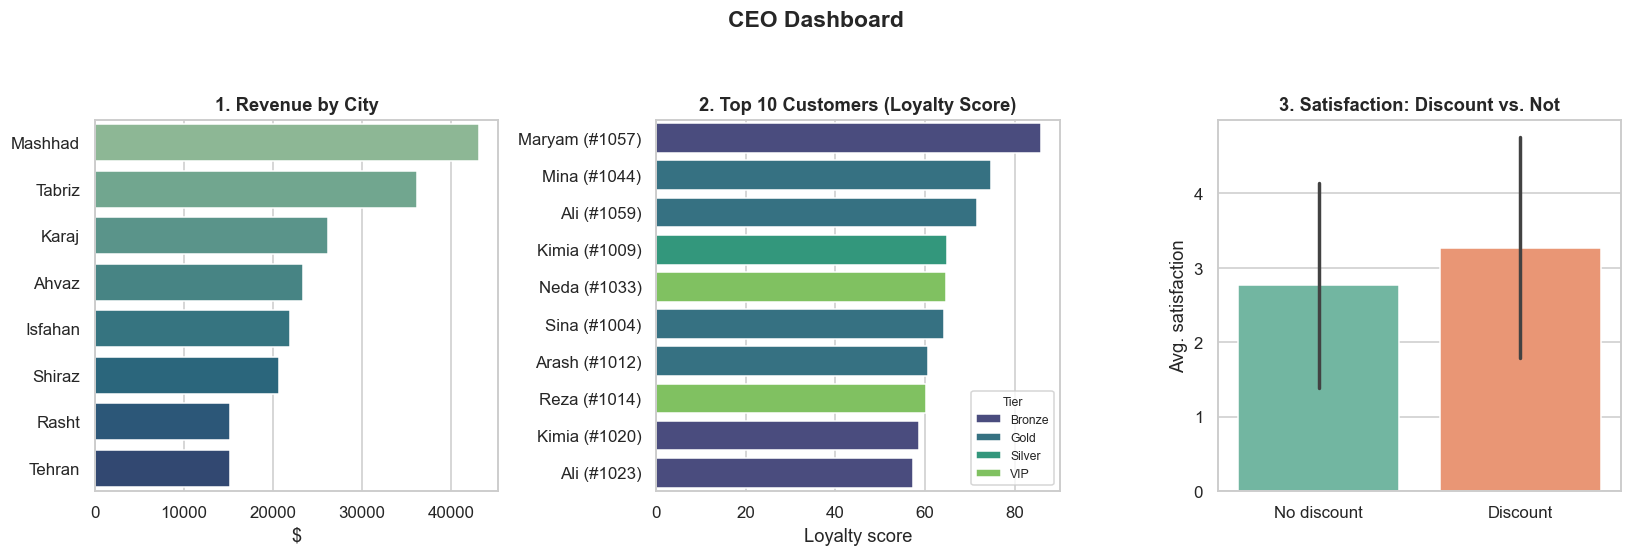

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

sns.barplot(x=city_stats["total_revenue"], y=city_stats.index.get_level_values("city"),
            hue=city_stats.index.get_level_values("city"), palette="crest", ax=axes[0], legend=False)
axes[0].set_title("1. Revenue by City"); axes[0].set_xlabel("$"); axes[0].set_ylabel("")

sns.barplot(data=top10, x="loyalty_score", y=top10["first_name"] + " (#" + top10["customer_id"].astype(str) + ")",
            hue="membership_tier", dodge=False, palette="viridis", ax=axes[1])
axes[1].set_title("2. Top 10 Customers (Loyalty Score)"); axes[1].set_xlabel("Loyalty score"); axes[1].set_ylabel("")
axes[1].legend(title="Tier", fontsize=8, title_fontsize=8)

sns.barplot(data=df, x="discount_used", y="satisfaction_score", hue="discount_used",
            palette="Set2", ax=axes[2], legend=False, errorbar="sd")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["No discount", "Discount"])
axes[2].set_title("3. Satisfaction: Discount vs. Not"); axes[2].set_xlabel(""); axes[2].set_ylabel("Avg. satisfaction")

plt.suptitle("CEO Dashboard", fontsize=15, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("charts/06_ceo_report_3charts.png", bbox_inches="tight", dpi=130)
plt.show()


### 3 Recommendations (KPI → Evidence → Action)

**1. KPI: City-level revenue concentration**
**Evidence:** Mashhad generates ~21% of total revenue (~$43,198) with 11 customers, ahead of every other city on total revenue even though Tabriz has more customers (12).
**Action:** Launch the next marketing campaign in Mashhad; run a smaller high-touch pilot in Isfahan, which leads on satisfaction (4.4/5) and average spend per customer.

**2. KPI: Membership-tier average spend inconsistency**
**Evidence:** Average spend is not monotonic across tiers — Silver customers out-spend both Gold and VIP, and VIP has the lowest average spend of all four tiers (see Additional Analysis, §7.2).
**Action:** Audit the `membership_tier` assignment logic before using it for targeting; use the Loyalty Score (Question 3) or RFM segments (§7.3) as the interim substitute for value-based decisions.

**3. KPI: Satisfaction gap between discount users and non-users**
**Evidence:** Discount users report satisfaction of 3.27/5 vs. 2.76/5 for non-users — a meaningful gap directionally, but not statistically significant at n=60 (p=0.184 from the t-test above).
**Action:** Run a controlled A/B test on discount targeting before scaling it as a satisfaction lever — the current evidence is promising but not yet proof.


---
## 7. Additional Analysis (Beyond the Six Required Questions)

The sections below are **not** part of the six graded questions — they're extra analysis that goes further than the brief, kept here so nothing developed for the CEO report gets lost, but clearly separated so it doesn't crowd the required answers above.


### 7.1 Pareto Analysis — does 20% of customers drive 80% of revenue?

28 customers (46.7% of the base) generate 80% of revenue.
The top 20% of customers (12 people) generate 51.0% of revenue.


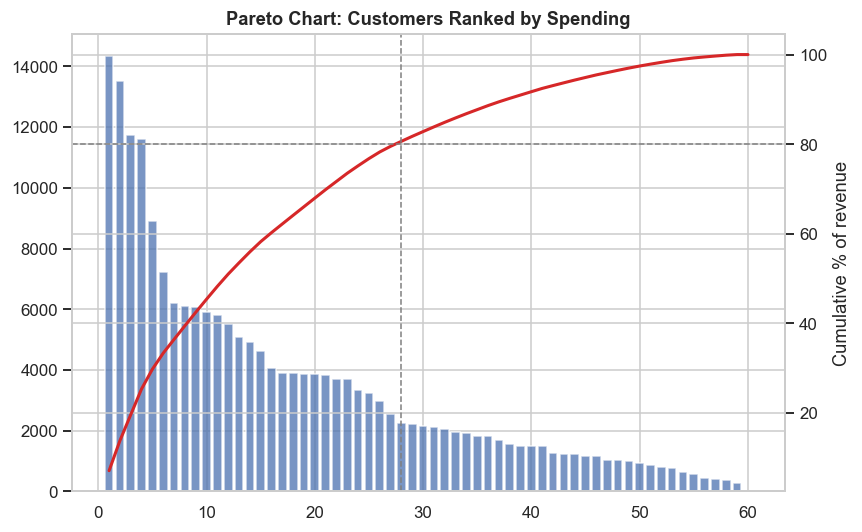

In [28]:
sorted_df = df.sort_values("total_spending", ascending=False).reset_index(drop=True)
sorted_df["cum_revenue_pct"] = sorted_df["total_spending"].cumsum() / total_revenue * 100

n_for_80 = (sorted_df["cum_revenue_pct"] < 80).sum() + 1
pct_for_80 = n_for_80 / len(sorted_df) * 100
top20_n = int(np.ceil(len(sorted_df) * 0.2))
top20_share = sorted_df.iloc[:top20_n]["total_spending"].sum() / total_revenue * 100

print(f"{n_for_80} customers ({pct_for_80:.1f}% of the base) generate 80% of revenue.")
print(f"The top 20% of customers ({top20_n} people) generate {top20_share:.1f}% of revenue.")

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(sorted_df) + 1), sorted_df["total_spending"], color="#4c72b0", alpha=0.75)
ax2 = plt.twinx()
ax2.plot(range(1, len(sorted_df) + 1), sorted_df["cum_revenue_pct"], color="#d62728", linewidth=2)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.axvline(n_for_80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative % of revenue")
plt.title("Pareto Chart: Customers Ranked by Spending")
plt.xlabel("Customers, ranked from highest to lowest spender")
plt.tight_layout()
plt.savefig("charts/07a_pareto.png", bbox_inches="tight")
plt.show()


The classic 80/20 rule does **not** strictly hold here — the label "80/20" describes a common pattern, not a law, and this dataset simply doesn't follow it that tightly. It takes a larger share of customers than 20% to reach 80% of revenue; the top 20% still generate a disproportionate, but less extreme, share of revenue. Retention efforts need to reach further into the base than "just the top decile" to protect most of the revenue.


### 7.2 Membership Tier vs. Actual Spending — a data-quality flag

In [29]:
tier_summary = df.groupby("membership_tier")[["total_spending", "purchase_count", "satisfaction_score"]].mean().round(1)
tier_summary = tier_summary.reindex(["Bronze", "Silver", "Gold", "VIP"])
tier_summary["n_customers"] = df["membership_tier"].value_counts().reindex(["Bronze","Silver","Gold","VIP"])
tier_summary


,total_spending,purchase_count,satisfaction_score,n_customers
membership_tier,,,,
Bronze,3166.7,16.9,3.1,18
Silver,4179.9,16.5,2.5,8
Gold,3955.4,17.1,2.7,19
VIP,2426.2,18.9,3.4,15


Average spending does **not** increase monotonically with tier: **Silver customers out-spend both Gold and VIP**, and VIP has the *lowest* average spend of the four tiers. Either the tier-assignment logic isn't based on lifetime spend, or VIP status is granted for reasons unrelated to value. Until this is audited, `membership_tier` should not be trusted as a value proxy — this is why Question 3 builds an independent Loyalty Score rather than relying on tier.


### 7.3 RFM + K-Means Clustering (Unsupervised ML)

In [30]:
rfm = df[["customer_id", "last_purchase_days", "purchase_count", "total_spending"]].copy()
rfm.columns = ["customer_id", "Recency", "Frequency", "Monetary"]
X_scaled = StandardScaler().fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

k_range = range(2, 8)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

print("Silhouette score by k:", {k: round(s, 3) for k, s in zip(k_range, sil_scores)})
best_sil_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Highest silhouette score is at k={best_sil_k} ({max(sil_scores):.3f}).")


D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette score by k: {2: 0.313, 3: 0.306, 4: 0.331, 5: 0.362, 6: 0.368, 7: 0.357}
Highest silhouette score is at k=6 (0.368).


D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [31]:
BEST_K = 4  # chosen for business interpretability, NOT because it has the top silhouette score
km = KMeans(n_clusters=BEST_K, n_init=10, random_state=RNG).fit(X_scaled)
rfm["cluster"] = km.labels_

seg_summary = rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
seg_summary["count"] = rfm["cluster"].value_counts()
seg_summary.sort_values("Monetary", ascending=False)


D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Recency,Frequency,Monetary,count
cluster,,,,
2,185.4,31.2,12026.5,5
0,231.5,24.2,3846.7,24
3,92.5,12.9,2072.8,17
1,275.9,6.2,1021.0,14


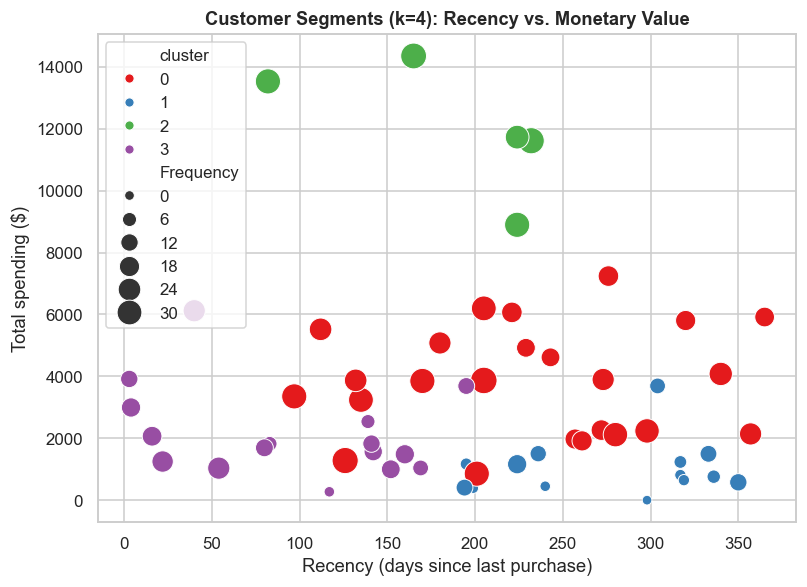

In [32]:
plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="cluster", size="Frequency",
                 sizes=(40, 300), palette="Set1")
plt.title("Customer Segments (k=4): Recency vs. Monetary Value")
plt.xlabel("Recency (days since last purchase)"); plt.ylabel("Total spending ($)")
plt.tight_layout()
plt.savefig("charts/07b_kmeans_clusters.png", bbox_inches="tight")
plt.show()


**Important correction:** the silhouette score is actually *highest* at k=6 (0.368), not at k=4. **k=4 is used here anyway, deliberately, for business interpretability** (four clean, nameable segments are easier for a CEO to act on than six overlapping ones) — this is a conscious trade-off, not a claim that k=4 is the statistically optimal clustering. The four resulting groups (highest to lowest value): **Champions** (recent + high spend), **High-Value At-Risk** (big historical spend, going quiet — overlaps with Question 4), **New/Promising** (recent, moderate activity), and **Low-Value/Lapsed** (infrequent, low spend, inactive).


### 7.4 Correlation Structure & Tenure

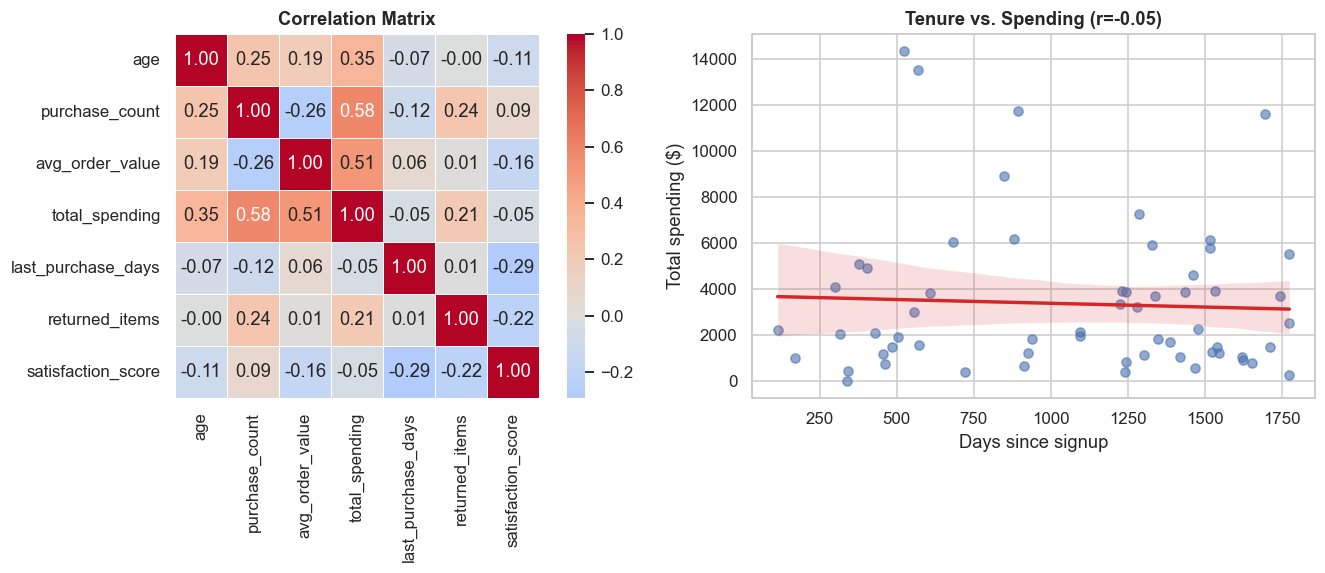

In [33]:
num_cols = ["age", "purchase_count", "avg_order_value", "total_spending",
            "last_purchase_days", "returned_items", "satisfaction_score"]
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title("Correlation Matrix")

df["tenure_days"] = (pd.Timestamp("2026-01-01") - df["signup_date"]).dt.days
sns.regplot(data=df, x="tenure_days", y="total_spending", scatter_kws={"alpha":0.6},
            line_kws={"color":"#d62728"}, ax=axes[1])
axes[1].set_title(f"Tenure vs. Spending (r={df['tenure_days'].corr(df['total_spending']):.2f})")
axes[1].set_xlabel("Days since signup"); axes[1].set_ylabel("Total spending ($)")

plt.tight_layout()
plt.savefig("charts/07c_correlation_tenure.png", bbox_inches="tight")
plt.show()


No strong linear relationships appear among the numeric features (all |r| < 0.4). Tenure in particular has almost no relationship with spending (r ≈ -0.05) — a long-time customer is not automatically a high-value one here, reinforcing why a multi-factor Loyalty Score (Question 3) beats any single-column ranking.


### 7.5 Supervised ML — Churn-Risk Classifier (illustrative only)

Using the **valuable-at-risk** label from Question 4 as the target. **This did not perform well, and the result should not be treated as a business finding** — it's included to show the approach and to be transparent about where it falls short at this sample size.


In [34]:
feature_cols = ["age", "purchase_count", "avg_order_value", "total_spending", "returned_items", "discount_used"]
X_ml = df[feature_cols].copy()
X_ml["discount_used"] = X_ml["discount_used"].astype(int)
y_ml = df["at_risk_valuable"].astype(int)
print("Class balance:", y_ml.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.3, random_state=RNG, stratify=y_ml)
clf = RandomForestClassifier(n_estimators=300, max_depth=4, class_weight="balanced", random_state=RNG)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Not at risk", "At risk"], zero_division=0))
print(f"ROC-AUC (test set): {roc_auc_score(y_test, y_proba):.2f}")


Class balance: {0: 54, 1: 6}
              precision    recall  f1-score   support

 Not at risk       0.89      1.00      0.94        16
     At risk       0.00      0.00      0.00         2

    accuracy                           0.89        18
   macro avg       0.44      0.50      0.47        18
weighted avg       0.79      0.89      0.84        18

ROC-AUC (test set): 0.66


**Honest read of the result:** with only 6 positive cases in 60 rows, the model achieves **0% recall on the at-risk class** (it misses every at-risk customer in the test split) and a **weak ROC-AUC (~0.6-0.7, close to random)**. This is a genuine limitation, not a rounding error — **the model does not work well enough to trust its feature importances as a business insight**, and I'm not presenting them here for that reason. The rule-based definition in Question 4 remains the reliable approach at this sample size; a supervised model would need meaningfully more labeled data (ideally hundreds of customers and more true at-risk cases) before its output should influence real decisions.


## 8. Limitations of This Dataset

- **Small sample size (n=60).** Most statistical tests in this notebook (discount comparison, city differences) are underpowered — directional findings should be treated as hypotheses, not conclusions.
- **No true item return rate is computable.** `returned_items` counts items, while `purchase_count` counts orders/transactions — these are different units, and the dataset does not include the total number of items purchased, which a real return rate would require. Any "return rate" figure computed as `returned_items / purchase_count` (as an earlier draft of this notebook did) is not a valid rate and has been removed from the KPIs.
- **Single snapshot, no per-transaction history.** We only see cumulative/summary fields, so trends, seasonality, and whether behavior is accelerating or decelerating are invisible.
- **No cost or margin data.** All revenue-based recommendations use `total_spending` as a proxy for value; actual business impact depends on unseen margins.
- **`membership_tier` appears unreliable** (§7.2) — its assignment logic isn't documented in the data and doesn't track spending.
- **The "at-risk" label (Question 4) is a heuristic I defined**, not an observed/confirmed churn event.
- **No acquisition-channel or marketing-spend data** — the city recommendation addresses where existing customers are healthiest, not necessarily where a marketing dollar goes furthest.
- **Severe class imbalance** in the at-risk label (6 positive vs. 54 negative) makes the supervised churn model in §7.5 unreliable; it's included for methodological transparency, not as a finding.


## Summary — Answering the CEO's Question

*How can this analysis help the CEO make better business decisions?*

It replaces intuition with three concrete, evidence-backed actions from the CEO Report (Question 6): **where to spend the next marketing dollar (Mashhad)**, **which internal system to fix before it misleads future targeting (the membership-tier logic)**, and **which discount hypothesis to test properly before scaling it**. Question 4 adds a short, split action list for 6 valuable customers going quiet (~$27,422 of revenue) — a service-recovery track for the 3 who are unhappy, and a lighter re-engagement track for the 3 who simply drifted. Throughout, the notebook is explicit about where the data is too thin to justify full confidence (sample size, the invalid return-rate metric, the underpowered churn model), so decisions get made with appropriate confidence rather than false precision.
